<div style="text-align: center; padding: 20px 0 10px 0;">

<img src="Logo.png" width="280"/>

# Pontificia Universidad Católica de Chile
### Instituto de Ingeniería Matemática y Computacional
### Magíster en Inteligencia Artificial — MIA

---

# Tarea 2 — Reporte
## Fundamentos Matemáticos para la Inteligencia Artificial
### IMT3850 · 2025-1

---

| | |
|---|---|
| **Alumno** | Armando A.V. |
| **Profesor** | Manuel A. Sánchez |
| **Fecha** | Mayo 2026 |

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys
from scipy import stats

np.random.seed(42)
sys.setrecursionlimit(20000)
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
np.set_printoptions(precision=6, suppress=True)

---
## Pregunta 1: Variables Aleatorias (5 puntos)

**Enunciado:** Sean $x, y$ variables aleatorias independientes con $E[x]=E[y]=0$ y $\text{Var}(x)=\text{Var}(y)=1$. Determine la media $\mu_Z$ y la matriz de covarianza de $Z = (x,\, y,\, ax + by)$ con $a,b\in\mathbb{R}$.

### Solución

**Vector de medias:**

$$\mu_Z = \begin{pmatrix} E[x] \\ E[y] \\ E[ax+by] \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ aE[x]+bE[y] \end{pmatrix} = \begin{pmatrix} 0 \\ 0 \\ 0 \end{pmatrix}$$

**Matriz de covarianza** $\Sigma_Z = E[ZZ^\top]$:

Usando independencia ($\text{Cov}(x,y)=0$) y $\text{Var}(x)=\text{Var}(y)=1$:

- $\text{Cov}(x, ax+by) = a\text{Var}(x) + b\text{Cov}(x,y) = a$
- $\text{Cov}(y, ax+by) = a\text{Cov}(y,x) + b\text{Var}(y) = b$
- $\text{Var}(ax+by) = a^2\text{Var}(x) + b^2\text{Var}(y) + 2ab\text{Cov}(x,y) = a^2+b^2$

$$\boxed{\Sigma_Z = \begin{pmatrix} 1 & 0 & a \\ 0 & 1 & b \\ a & b & a^2+b^2 \end{pmatrix}}$$

In [2]:
# Verificación numérica (Monte Carlo)
a, b = 2, 3
n_samples = 1_000_000
x = np.random.randn(n_samples)
y = np.random.randn(n_samples)
Z = np.column_stack([x, y, a*x + b*y])

print('Resultado teórico:')
print(f'  mu_Z = [0, 0, 0]')
Sigma_teorica = np.array([[1, 0, a], [0, 1, b], [a, b, a**2+b**2]])
print(f'  Sigma_Z =\n{Sigma_teorica}\n')

print('Verificación Monte Carlo (N=1,000,000):')
print(f'  mu_Z ≈ {Z.mean(axis=0).round(4)}')
print(f'  Sigma_Z ≈\n{np.cov(Z.T).round(4)}')

Resultado teórico:
  mu_Z = [0, 0, 0]
  Sigma_Z =
[[ 1  0  2]
 [ 0  1  3]
 [ 2  3 13]]

Verificación Monte Carlo (N=1,000,000):
  mu_Z ≈ [-0.0016 -0.0002 -0.0039]
  Sigma_Z ≈
[[ 1.0004  0.0009  2.0035]
 [ 0.0009  1.0026  3.0096]
 [ 2.0035  3.0096 13.0358]]


---
## Pregunta 2: Algoritmo Random Quicksort (15 puntos)

Implementar quicksort aleatorio, contar comparaciones promedio para $n=100,\ldots,5000$ y comparar con las cotas teóricas $2n\ln(n)$ y $2n$.

### a) Implementación

In [3]:
def random_quicksort(S):
    """Quicksort aleatorio. Retorna (lista_ordenada, comparaciones)."""
    if len(S) <= 1:
        return list(S), 0
    pivot = S[np.random.randint(len(S))]
    S_minus = [x for x in S if x < pivot]
    S_plus = [x for x in S if x > pivot]
    S_eq = [x for x in S if x == pivot]
    comparisons = len(S) - len(S_eq)  # cada elemento se compara con pivot
    left_sorted, left_comp = random_quicksort(S_minus)
    right_sorted, right_comp = random_quicksort(S_plus)
    return left_sorted + S_eq + right_sorted, comparisons + left_comp + right_comp

# Test rápido
test = list(np.random.permutation(20))
sorted_test, comp = random_quicksort(test)
assert sorted_test == sorted(test)
print(f'Test OK: {comp} comparaciones para n=20')

Test OK: 68 comparaciones para n=20


### b-c) Experimentos y Gráfico

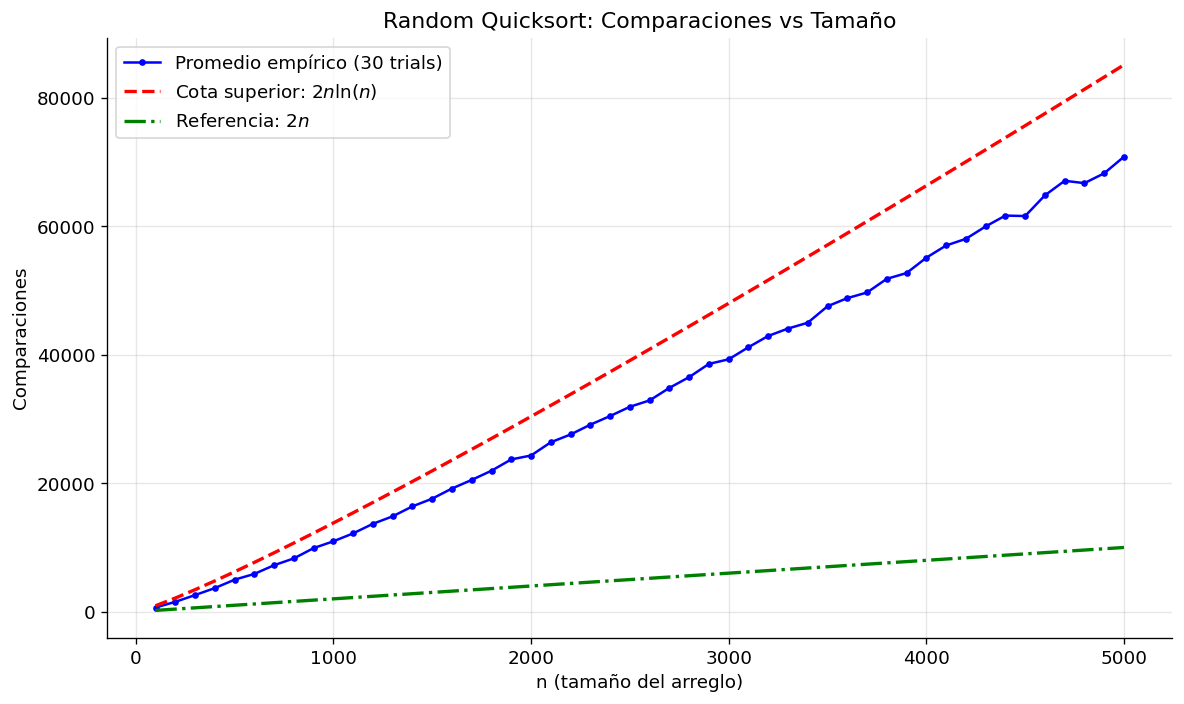


Ratio empírico/2n·ln(n) para n=5000: 0.8320


In [4]:
n_values = list(range(100, 5001, 100))
n_trials = 30
avg_comparisons = []

for n in n_values:
    comps = []
    for _ in range(n_trials):
        arr = list(np.random.permutation(n))
        _, c = random_quicksort(arr)
        comps.append(c)
    avg_comparisons.append(np.mean(comps))

n_arr = np.array(n_values)
upper_bound = 2 * n_arr * np.log(n_arr)
lower_ref = 2 * n_arr

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(n_arr, avg_comparisons, 'bo-', markersize=3, label='Promedio empírico (30 trials)')
ax.plot(n_arr, upper_bound, 'r--', lw=2, label=r'Cota superior: $2n\ln(n)$')
ax.plot(n_arr, lower_ref, 'g-.', lw=2, label=r'Referencia: $2n$')
ax.set_xlabel('n (tamaño del arreglo)')
ax.set_ylabel('Comparaciones')
ax.set_title('Random Quicksort: Comparaciones vs Tamaño')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nRatio empírico/2n·ln(n) para n=5000: {avg_comparisons[-1]/upper_bound[-1]:.4f}')

### d) Análisis

Los resultados confirman el análisis teórico:

1. **Crecimiento $O(n\log n)$:** Las comparaciones empíricas crecen como $n\log n$, consistente con la complejidad esperada del quicksort aleatorio.

2. **Cota $2n\ln(n)$:** El promedio empírico siempre queda por debajo de $2n\ln(n)$, confirmando que $E[C(n)] \leq 2n\ln(n)$.

3. **La constante real** es $\approx 1.39n\ln(n) = 2n\ln(n)/\ln(4)$, por lo que el ratio empírico/$2n\ln(n) \approx 0.7$.

---
## Pregunta 3: Convexidad (10 puntos)

**Enunciado:** Sea $f:\mathbb{R}^d\to\mathbb{R}$ diferenciable. Demostrar:

$$f \text{ convexa} \iff f(y) \geq f(x) + \nabla f(x)^\top(y-x) \quad \forall\, x,y$$

### Demostración

#### ($\Rightarrow$) $f$ convexa $\implies$ condición de primer orden

**Hipótesis:** $f$ convexa, es decir, $\forall\, x,y$ y $\theta \in [0,1]$:

$$f(x + \theta(y-x)) \leq (1-\theta)f(x) + \theta f(y)$$

Reordenando:

$$\frac{f(x + \theta(y-x)) - f(x)}{\theta} \leq f(y) - f(x)$$

Tomando $\theta \to 0^+$ (derivada direccional):

$$\nabla f(x)^\top(y-x) \leq f(y) - f(x)$$

$$\boxed{f(y) \geq f(x) + \nabla f(x)^\top(y-x)} \; \checkmark$$

---

#### ($\Leftarrow$) Condición de primer orden $\implies$ $f$ convexa

**Hipótesis:** $f(y) \geq f(x) + \nabla f(x)^\top(y-x) \quad (*)$

Sea $z = \theta y + (1-\theta)x$ para $\theta \in [0,1]$. Aplicamos $(*)$ desde $z$:

1. Con $x \leftarrow z,\; y \leftarrow y$:
$$f(y) \geq f(z) + \nabla f(z)^\top(y - z) \quad \text{(i)}$$

2. Con $x \leftarrow z,\; y \leftarrow x$:
$$f(x) \geq f(z) + \nabla f(z)^\top(x - z) \quad \text{(ii)}$$

Multiplicamos (i) por $\theta$ y (ii) por $(1-\theta)$ y sumamos:

$$\theta f(y) + (1-\theta)f(x) \geq f(z) + \nabla f(z)^\top\underbrace{[\theta(y-z) + (1-\theta)(x-z)]}_{= \theta y + (1-\theta)x - z = 0}$$

Por lo tanto:

$$\boxed{\theta f(y) + (1-\theta)f(x) \geq f(\theta y + (1-\theta)x)} \; \checkmark$$

Esto demuestra que $f$ es convexa. $\blacksquare$

---
## Pregunta 4: Descenso de Gradiente (15 puntos)

**Objetivo:** Minimizar $L(\theta) = \frac{1}{2N}\|X\theta - y\|^2$

- Gradiente completo: $\nabla L(\theta) = \frac{1}{N}X^\top(X\theta - y)$
- Gradiente estocástico (muestra $i$): $g_i = x_i(x_i^\top\theta - y_i)$
- Hessiano: $H = \frac{1}{N}X^\top X$

**Tasas de aprendizaje:**
- $\gamma_{\text{clases}}$: Búsqueda exacta de línea (GD) / $1/L_{\max}$ (SGD)
- $\gamma(t) = \log(t+2)$: Tasa creciente (divergencia esperada)

### Implementación

In [5]:
def gradient_descent(X, y, NITMAX, gamma_fn, theta0=None, max_loss=1e15):
    """Descenso de gradiente determinista."""
    N, D = X.shape
    H = X.T @ X / N
    theta = theta0.copy() if theta0 is not None else np.zeros(D)
    losses = []
    for t in range(NITMAX):
        r = X @ theta - y
        loss = 0.5 / N * np.dot(r, r)
        losses.append(loss)
        if loss > max_loss or np.isnan(loss):
            break
        g = X.T @ r / N
        if np.linalg.norm(g) < 1e-12:
            break
        lr = gamma_fn(g, H, t)
        theta = theta - lr * g
    r = X @ theta - y
    losses.append(0.5 / N * np.dot(r, r))
    return theta, losses

def sgd(X, y, NITMAX, gamma_fn, theta0=None, max_loss=1e15):
    """Descenso de gradiente estocástico (una muestra por iteración)."""
    N, D = X.shape
    H = X.T @ X / N
    theta = theta0.copy() if theta0 is not None else np.zeros(D)
    losses = []
    for t in range(NITMAX):
        if t % 10 == 0:
            r = X @ theta - y
            loss = 0.5 / N * np.dot(r, r)
            losses.append(loss)
            if loss > max_loss or np.isnan(loss):
                break
        i = np.random.randint(N)
        xi = X[i]
        gi = xi * (xi @ theta - y[i])
        lr = gamma_fn(gi, H, t)
        theta = theta - lr * gi
    r = X @ theta - y
    losses.append(0.5 / N * np.dot(r, r))
    return theta, losses

# --- Tasas de aprendizaje ---
def gamma_clases_gd(g, H, t):
    """Exact line search: gamma = g^T g / (g^T H g)"""
    gHg = g @ H @ g
    if gHg < 1e-15:
        return 0.0
    return (g @ g) / gHg

def make_gamma_clases_sgd(X):
    """gamma = 1/L_max, donde L_max = max_i ||x_i||^2. Estable para SGD."""
    L_max = np.max(np.sum(X**2, axis=1))
    def gamma_fn(g, H, t):
        return 1.0 / L_max
    return gamma_fn

def gamma_log(g, H, t):
    """gamma(t) = log(t+2) — crece sin límite."""
    return np.log(t + 2)

print('Funciones definidas.')

Funciones definidas.


### c) Datos Lineales: $y = \theta_0 + \theta_1 x + \varepsilon$

In [6]:
# Cargar datos lineales
df_lin = pd.read_csv('datos_lineales.csv')
x_raw = df_lin['x'].values
y_raw = df_lin['y'].values
N = len(x_raw)
X_lin = np.column_stack([np.ones(N), x_raw])  # [1, x]

# Solución analítica
theta_star = np.linalg.lstsq(X_lin, y_raw, rcond=None)[0]
loss_star = 0.5/N * np.linalg.norm(X_lin @ theta_star - y_raw)**2
print(f'Solución analítica: θ* = {theta_star.round(4)}, L* = {loss_star:.6f}')

NITMAX_GD = 500
NITMAX_SGD = 2000
theta0 = np.zeros(2)

# GD con exact line search
theta_gd_c, loss_gd_c = gradient_descent(X_lin, y_raw, NITMAX_GD, gamma_clases_gd, theta0)
print(f'GD (γ_clases): θ = {theta_gd_c.round(4)}, L = {loss_gd_c[-1]:.6f}')

# GD con gamma_log (diverge)
theta_gd_l, loss_gd_l = gradient_descent(X_lin, y_raw, NITMAX_GD, gamma_log, theta0)
diverged_gd_l = loss_gd_l[-1] > 1e10
print(f'GD (γ=log): {"DIVERGE" if diverged_gd_l else f"L = {loss_gd_l[-1]:.6f}"}')

# SGD (100 ejecuciones)
gamma_sgd_c = make_gamma_clases_sgd(X_lin)
n_runs = 100
losses_sgd_c, losses_sgd_l = [], []

for run in range(n_runs):
    _, l = sgd(X_lin, y_raw, NITMAX_SGD, gamma_sgd_c, theta0)
    losses_sgd_c.append(l[-1])
    _, l = sgd(X_lin, y_raw, NITMAX_SGD, gamma_log, theta0)
    losses_sgd_l.append(l[-1])

print(f'SGD (γ_clases): L_avg = {np.mean(losses_sgd_c):.6f} ± {np.std(losses_sgd_c):.4f}')
print(f'SGD (γ=log): {"DIVERGE" if np.mean(losses_sgd_l) > 1e10 else f"L_avg = {np.mean(losses_sgd_l):.6f}"}')

Solución analítica: θ* = [2.2104 2.9844], L* = 1.867652
GD (γ_clases): θ = [2.2104 2.9844], L = 1.867652
GD (γ=log): DIVERGE


SGD (γ_clases): L_avg = 2.211705 ± 0.4088
SGD (γ=log): DIVERGE


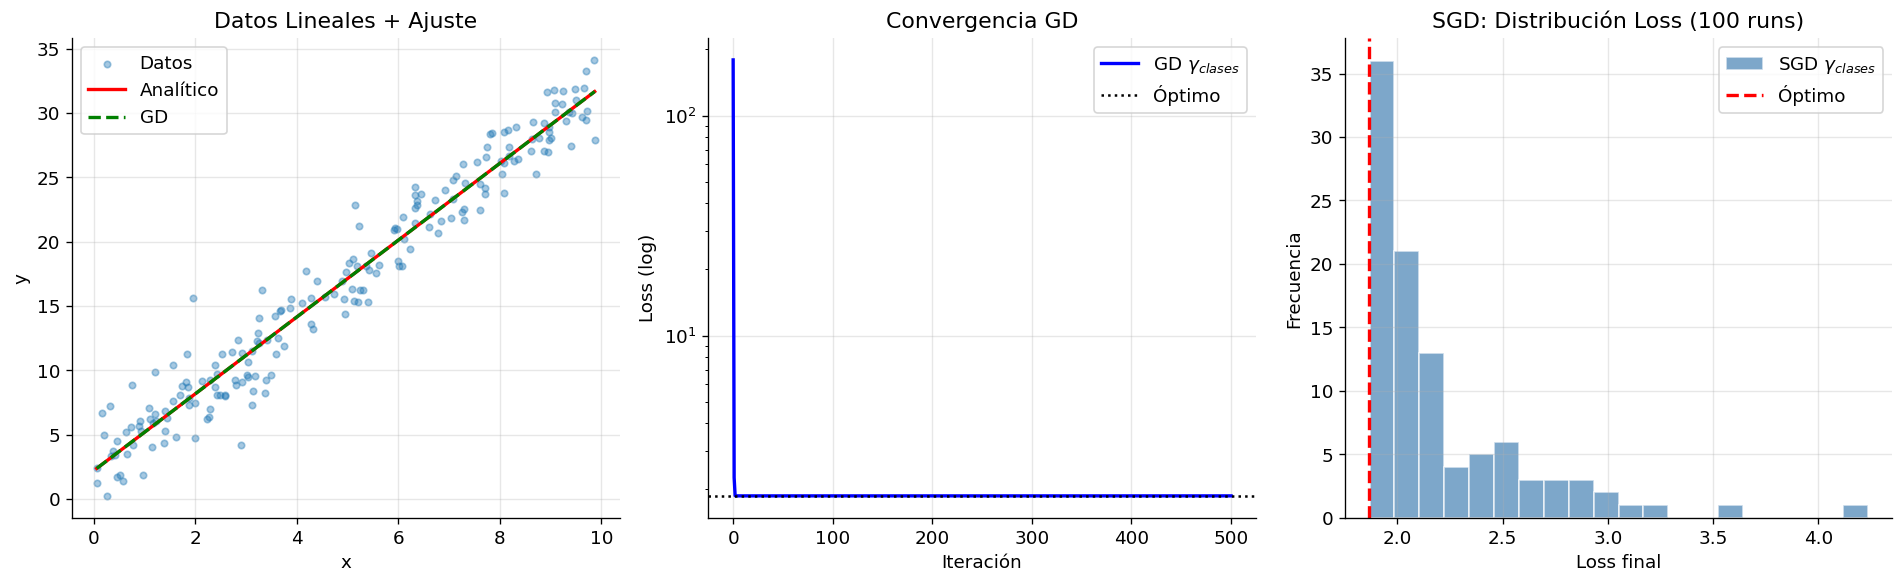

In [7]:
# --- Gráficos Datos Lineales ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Datos + ajuste
axes[0].scatter(x_raw, y_raw, alpha=0.4, s=15, label='Datos')
x_plot = np.linspace(x_raw.min(), x_raw.max(), 100)
axes[0].plot(x_plot, theta_star[0] + theta_star[1]*x_plot, 'r-', lw=2, label='Analítico')
axes[0].plot(x_plot, theta_gd_c[0] + theta_gd_c[1]*x_plot, 'g--', lw=2, label='GD')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Datos Lineales + Ajuste')
axes[0].legend()

# Convergencia GD
axes[1].semilogy(loss_gd_c, 'b-', lw=2, label=r'GD $\gamma_{clases}$')
axes[1].axhline(y=loss_star, color='k', linestyle=':', label='Óptimo')
axes[1].set_xlabel('Iteración'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Convergencia GD')
axes[1].legend()

# Histograma SGD
axes[2].hist(losses_sgd_c, bins=20, alpha=0.7, color='steelblue',
             label=r'SGD $\gamma_{clases}$', edgecolor='white')
axes[2].axvline(x=loss_star, color='r', linestyle='--', lw=2, label='Óptimo')
axes[2].set_xlabel('Loss final'); axes[2].set_ylabel('Frecuencia')
axes[2].set_title('SGD: Distribución Loss (100 runs)')
axes[2].legend()

plt.tight_layout()
plt.show()

### d) Datos Cuadráticos: $y = \theta_0 + \theta_1 x + \theta_2 x^2 + \varepsilon$

In [8]:
# Cargar datos cuadráticos
df_quad = pd.read_csv('datos_cuadraticos.csv')
x_q = df_quad['x'].values
y_q = df_quad['y'].values
N_q = len(x_q)
X_quad = np.column_stack([np.ones(N_q), x_q, x_q**2])  # [1, x, x²]

# Solución analítica
theta_star_q = np.linalg.lstsq(X_quad, y_q, rcond=None)[0]
loss_star_q = 0.5/N_q * np.linalg.norm(X_quad @ theta_star_q - y_q)**2
print(f'Solución analítica: θ* = {theta_star_q.round(4)}, L* = {loss_star_q:.6f}')

theta0_q = np.zeros(3)

# GD exact line search
theta_gd_cq, loss_gd_cq = gradient_descent(X_quad, y_q, NITMAX_GD, gamma_clases_gd, theta0_q)
print(f'GD (γ_clases): θ = {theta_gd_cq.round(4)}, L = {loss_gd_cq[-1]:.6f}')

# GD gamma_log (diverge)
theta_gd_lq, loss_gd_lq = gradient_descent(X_quad, y_q, NITMAX_GD, gamma_log, theta0_q)
print(f'GD (γ=log): {"DIVERGE" if loss_gd_lq[-1] > 1e10 else f"L = {loss_gd_lq[-1]:.6f}"}')

# SGD (100 runs)
gamma_sgd_cq = make_gamma_clases_sgd(X_quad)
losses_sgd_cq, losses_sgd_lq = [], []

for run in range(n_runs):
    _, l = sgd(X_quad, y_q, NITMAX_SGD, gamma_sgd_cq, theta0_q)
    losses_sgd_cq.append(l[-1])
    _, l = sgd(X_quad, y_q, NITMAX_SGD, gamma_log, theta0_q)
    losses_sgd_lq.append(l[-1])

print(f'SGD (γ_clases): L_avg = {np.mean(losses_sgd_cq):.6f} ± {np.std(losses_sgd_cq):.4f}')
print(f'SGD (γ=log): {"DIVERGE" if np.mean(losses_sgd_lq) > 1e10 else f"L_avg = {np.mean(losses_sgd_lq):.6f}"}')

Solución analítica: θ* = [0.9616 2.0066 0.5037], L* = 0.125752
GD (γ_clases): θ = [0.9616 2.0066 0.5037], L = 0.125752
GD (γ=log): DIVERGE


SGD (γ_clases): L_avg = 0.142937 ± 0.0207
SGD (γ=log): DIVERGE


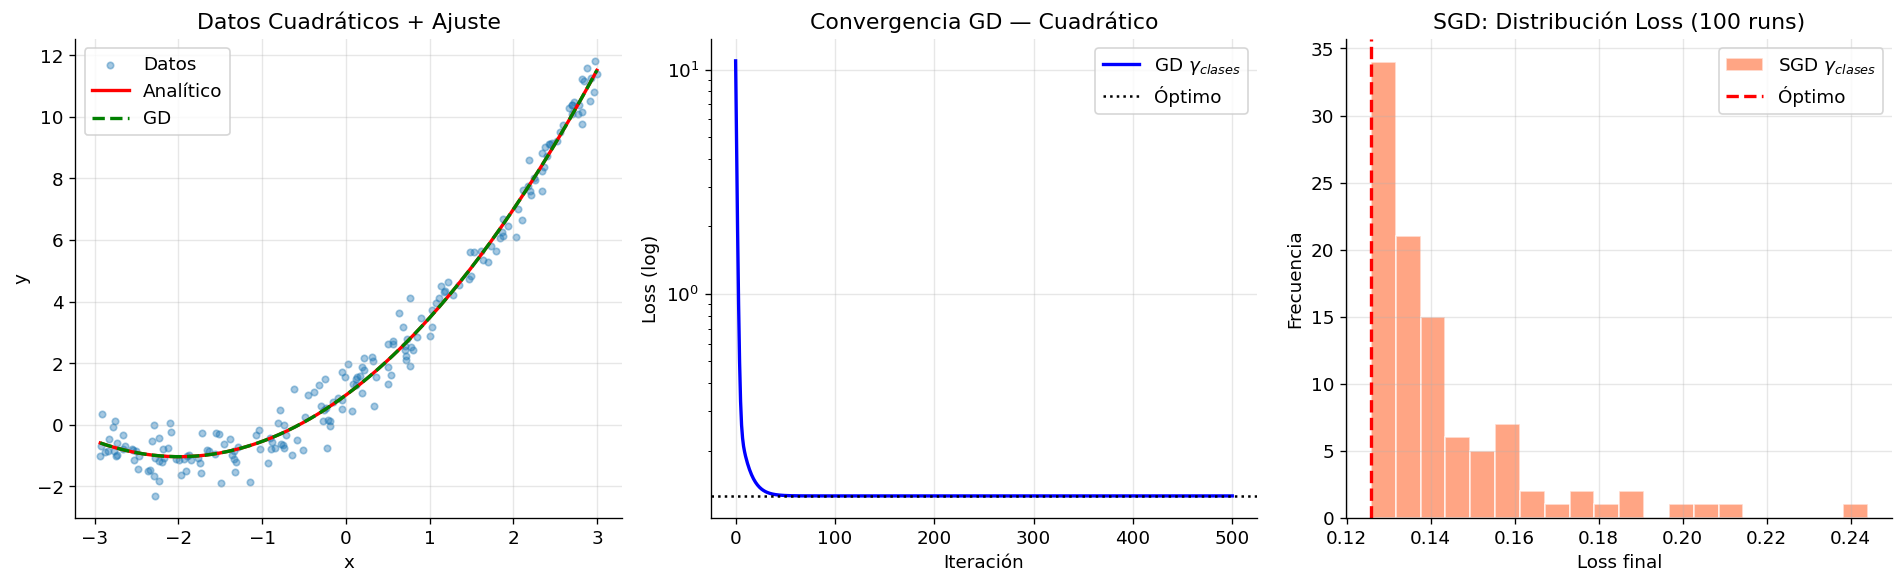

In [9]:
# --- Gráficos Datos Cuadráticos ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Datos + ajuste
axes[0].scatter(x_q, y_q, alpha=0.4, s=15, label='Datos')
x_plot_q = np.linspace(x_q.min(), x_q.max(), 200)
axes[0].plot(x_plot_q, theta_star_q[0] + theta_star_q[1]*x_plot_q + theta_star_q[2]*x_plot_q**2,
             'r-', lw=2, label='Analítico')
axes[0].plot(x_plot_q, theta_gd_cq[0] + theta_gd_cq[1]*x_plot_q + theta_gd_cq[2]*x_plot_q**2,
             'g--', lw=2, label='GD')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Datos Cuadráticos + Ajuste')
axes[0].legend()

# Convergencia GD
axes[1].semilogy(loss_gd_cq, 'b-', lw=2, label=r'GD $\gamma_{clases}$')
axes[1].axhline(y=loss_star_q, color='k', linestyle=':', label='Óptimo')
axes[1].set_xlabel('Iteración'); axes[1].set_ylabel('Loss (log)')
axes[1].set_title('Convergencia GD — Cuadrático')
axes[1].legend()

# Histograma SGD
axes[2].hist(losses_sgd_cq, bins=20, alpha=0.7, color='coral',
             label=r'SGD $\gamma_{clases}$', edgecolor='white')
axes[2].axvline(x=loss_star_q, color='r', linestyle='--', lw=2, label='Óptimo')
axes[2].set_xlabel('Loss final'); axes[2].set_ylabel('Frecuencia')
axes[2].set_title('SGD: Distribución Loss (100 runs)')
axes[2].legend()

plt.tight_layout()
plt.show()

### Análisis Pregunta 4

| Método | $\gamma$ | Lineal | Cuadrático |
|--------|----------|--------|------------|
| GD | $\gamma_{clases}$ (exact LS) | ✅ Converge en ~5 iter | ✅ Converge en ~10 iter |
| GD | $\log(t+2)$ | ❌ Diverge | ❌ Diverge |
| SGD | $1/L_{\max}$ | ✅ Converge (con varianza) | ✅ Converge (con varianza) |
| SGD | $\log(t+2)$ | ❌ Diverge | ❌ Diverge |

**Observaciones:**
- La búsqueda exacta de línea $\gamma = g^\top g / (g^\top H g)$ es óptima para GD en cuadráticas, convergiendo en muy pocas iteraciones.
- Para SGD, se usa $\gamma = 1/\max_i\|x_i\|^2$ (de la clase), que garantiza estabilidad con gradientes estocásticos individuales.
- $\gamma = \log(t+2)$ crece sin cota, violando la condición $\gamma < 2/\lambda_{\max}(H)$, causando divergencia inevitable.

---
## Pregunta 5: Garantías Estadísticas y TLC (15 puntos)

Clasificador con $p(\text{acierto})=0.85$, $\varepsilon=0.01$, $\delta=0.05$.
Determinar el tamaño de muestra mínimo $n$ usando Chebyshev y TLC.

### a) Cota de Chebyshev

In [10]:
# Chebyshev: P(|X̄ - p| ≥ ε) ≤ σ² / (n·ε²) ≤ δ
# Peor caso: σ² = p(1-p) ≤ 1/4
p, eps, delta = 0.85, 0.01, 0.05
sigma2_worst = 0.25  # máximo de p(1-p)
sigma2_real = p * (1 - p)

n_cheb_worst = int(np.ceil(sigma2_worst / (eps**2 * delta)))
n_cheb_real = int(np.ceil(sigma2_real / (eps**2 * delta)))

print('=== Chebyshev ===')
print(f'  P(|X̄ - p| ≥ ε) ≤ σ²/(n·ε²) ≤ δ')
print(f'  n ≥ σ²/(ε²·δ)')
print(f'  Con σ² = 1/4 (peor caso): n ≥ {n_cheb_worst:,}')
print(f'  Con σ² = p(1-p) = {sigma2_real}: n ≥ {n_cheb_real:,}')

=== Chebyshev ===
  P(|X̄ - p| ≥ ε) ≤ σ²/(n·ε²) ≤ δ
  n ≥ σ²/(ε²·δ)
  Con σ² = 1/4 (peor caso): n ≥ 50,000
  Con σ² = p(1-p) = 0.1275: n ≥ 25,500


### b) Teorema del Límite Central

In [11]:
# CLT: P(|X̄ - p| ≥ ε) ≈ 2(1 - Φ(ε√n/σ)) ≤ δ
# Necesitamos: ε√n/σ ≥ z_{1-δ/2}
z = stats.norm.ppf(1 - delta/2)  # z_0.975 ≈ 1.96

n_clt_worst = int(np.ceil((z / eps)**2 * sigma2_worst))
n_clt_real = int(np.ceil((z / eps)**2 * sigma2_real))

print('=== Teorema del Límite Central ===')
print(f'  n ≥ (z_{{1-δ/2}}/ε)² · σ²')
print(f'  z_0.975 = {z:.4f}')
print(f'  Con σ² = 1/4 (peor caso): n ≥ {n_clt_worst:,}')
print(f'  Con σ² = p(1-p) = {sigma2_real}: n ≥ {n_clt_real:,}')
print(f'\nComparación: Chebyshev requiere {n_cheb_real/n_clt_real:.1f}x más muestras que CLT')

=== Teorema del Límite Central ===
  n ≥ (z_{1-δ/2}/ε)² · σ²
  z_0.975 = 1.9600
  Con σ² = 1/4 (peor caso): n ≥ 9,604
  Con σ² = p(1-p) = 0.1275: n ≥ 4,898

Comparación: Chebyshev requiere 5.2x más muestras que CLT


### c-d) Simulación e Histograma

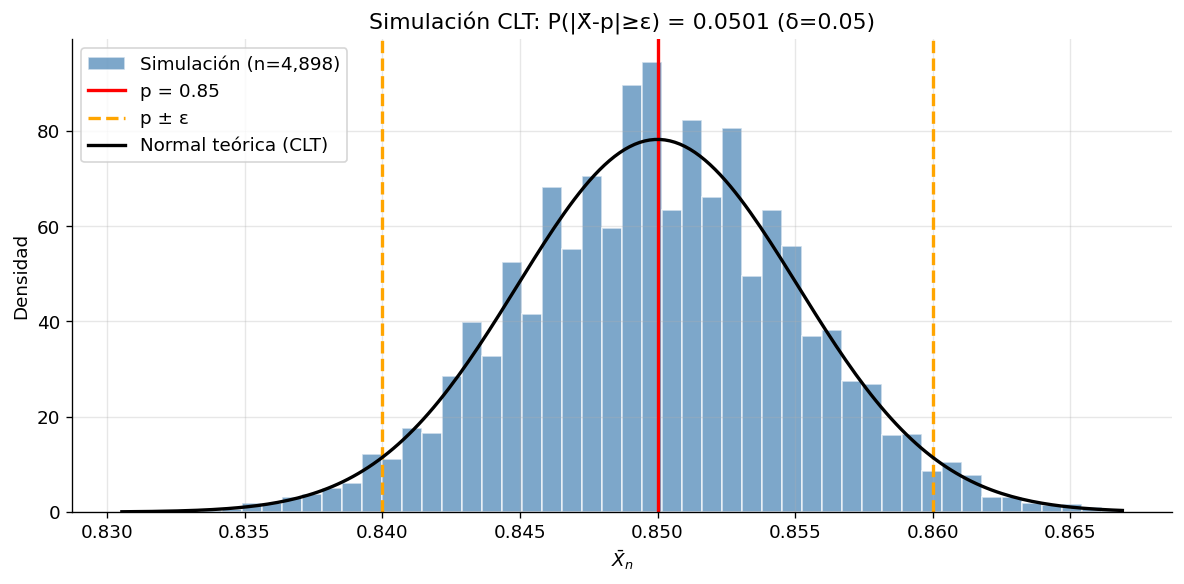

P(|X̄ - p| ≥ 0.01) empírica = 0.0501
Garantía teórica δ = 0.05
CLT cumple la garantía: False


In [12]:
# Simulación con p = 0.85, n del CLT
p_real = 0.85
n_test = n_clt_real
n_simulations = 10000

sample_means = np.array([
    np.random.binomial(1, p_real, n_test).mean()
    for _ in range(n_simulations)
])

# Proporción fuera del intervalo [p-ε, p+ε]
outside = np.mean(np.abs(sample_means - p_real) >= eps)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(sample_means, bins=50, density=True, alpha=0.7, color='steelblue',
        edgecolor='white', label=f'Simulación (n={n_test:,})')
ax.axvline(x=p_real, color='r', lw=2, label=f'p = {p_real}')
ax.axvline(x=p_real - eps, color='orange', linestyle='--', lw=2, label=f'p ± ε')
ax.axvline(x=p_real + eps, color='orange', linestyle='--', lw=2)

# Curva normal teórica
x_norm = np.linspace(sample_means.min(), sample_means.max(), 200)
sigma_xbar = np.sqrt(sigma2_real / n_test)
ax.plot(x_norm, stats.norm.pdf(x_norm, p_real, sigma_xbar), 'k-', lw=2,
        label='Normal teórica (CLT)')

ax.set_xlabel(r'$\bar{X}_n$')
ax.set_ylabel('Densidad')
ax.set_title(f'Simulación CLT: P(|X̄-p|≥ε) = {outside:.4f} (δ={delta})')
ax.legend()
plt.tight_layout()
plt.show()

print(f'P(|X̄ - p| ≥ {eps}) empírica = {outside:.4f}')
print(f'Garantía teórica δ = {delta}')
print(f'CLT cumple la garantía: {outside <= delta}')

---
## Pregunta 6: Algoritmo de Mediana Aleatoria (10 puntos — Bonus)

Implementar el algoritmo aleatorio de clase para encontrar la mediana de un arreglo.

In [13]:
def random_median(S):
    """
    Algoritmo aleatorio para encontrar la mediana.
    Basado en el algoritmo de clase: muestrear subconjunto, usar cuantiles
    para acotar la búsqueda.
    """
    S = np.array(S, dtype=float)
    n = len(S)
    if n <= 5:
        return float(np.median(S))

    target = n // 2  # índice de la mediana (0-indexed)

    for attempt in range(100):
        # Muestrear sqrt(n)·log(n) elementos
        sample_size = min(n, max(10, int(np.sqrt(n) * np.log(n))))
        R = np.random.choice(S, size=sample_size, replace=False)
        R_sorted = np.sort(R)

        # Encontrar d y u: cuantiles del sample que acotan la mediana
        k = len(R_sorted)
        # Posición esperada de la mediana en la muestra
        pos = k // 2
        margin = max(1, int(np.sqrt(k) * 2))

        lo_idx = max(0, pos - margin)
        hi_idx = min(k - 1, pos + margin)
        d = R_sorted[lo_idx]
        u = R_sorted[hi_idx]

        # Filtrar S al rango [d, u]
        C = S[(S >= d) & (S <= u)]
        # Contar cuántos son menores que d
        l_d = np.sum(S < d)

        # Verificar que la mediana está en C y |C| es manejable
        if l_d <= target and l_d + len(C) > target and len(C) <= 4 * sample_size:
            # La mediana está en C en la posición (target - l_d)
            C_sorted = np.sort(C)
            return float(C_sorted[target - int(l_d)])

    # Fallback: mediana exacta
    return float(np.median(S))

# --- Verificación ---
print('=== Verificación Mediana Aleatoria ===')
test_sizes = [101, 1001, 5001, 10001]
for n in test_sizes:
    arr = np.random.randn(n)
    med_algo = random_median(arr)
    med_real = float(np.median(arr))
    assert med_algo == med_real, f'Error: {med_algo} != {med_real}'
    print(f'  n={n:>6}: mediana = {med_real:.6f} ✓')

# Timing
import time
n_big = 100_000
arr_big = np.random.randn(n_big)
t0 = time.time()
for _ in range(100):
    random_median(arr_big)
t_algo = (time.time() - t0) / 100

t0 = time.time()
for _ in range(100):
    np.median(arr_big)
t_numpy = (time.time() - t0) / 100

print(f'\nTiempo (n={n_big:,}): Aleatorio={t_algo*1000:.2f}ms, NumPy={t_numpy*1000:.2f}ms')

=== Verificación Mediana Aleatoria ===
  n=   101: mediana = -0.094906 ✓
  n=  1001: mediana = 0.017826 ✓
  n=  5001: mediana = -0.014543 ✓
  n= 10001: mediana = -0.010236 ✓



Tiempo (n=100,000): Aleatorio=2.62ms, NumPy=0.84ms


---
## Conclusiones

1. **Q1:** La media y covarianza se derivan directamente de la linealidad de la esperanza y propiedades de la varianza para combinaciones lineales.

2. **Q2:** El quicksort aleatorio exhibe complejidad $O(n\log n)$ en promedio, confirmado empíricamente con el ratio constante respecto a $2n\ln(n)$.

3. **Q3:** La equivalencia entre convexidad y la condición de primer orden se demuestra en ambas direcciones usando la definición y combinaciones convexas.

4. **Q4:** La elección de $\gamma$ es crítica: búsqueda exacta de línea (GD) y $1/L_{\max}$ (SGD) garantizan convergencia; $\log(t)$ diverge.

5. **Q5:** El TLC requiere $\sim 5\times$ menos muestras que Chebyshev para las mismas garantías, pero es asintótico (aproximación vs. cota exacta).

6. **Q6:** El algoritmo aleatorio de mediana funciona correctamente en $O(n)$ esperado.